In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [ ]:
!unzip -q ./images.zip -d ./images

replace ./images/data/with_mask/with_mask_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
IMG_SIZE = 224

transform =transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])

])

In [ ]:
dataset = datasets.ImageFolder(root="images/data", transform=transform)

In [ ]:
from torch.utils.data import random_split
Batch_size =32
train_size =int(0.8 * len(dataset))
test_size= len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size,test_size])

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False)


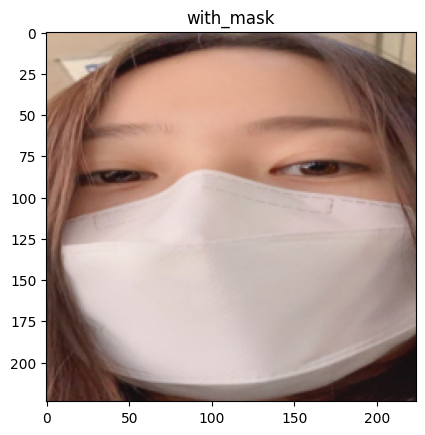

In [ ]:
def imshow(img,label):
    img = img / 2 +0.5
    npimg =img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.title(label)
    plt.show()

dataiter = iter(train_loader)
images, label = next(dataiter)

imshow(images[0],dataset.classes[label[0]])

In [ ]:
class CustomModel(nn.Module):
    def __init__(self,):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.pool= nn.MaxPool2d(2,2)

        self.fc1= nn.Linear(200704,128)
        self.fc2 =nn.Linear(128,2)

    def forward(self, x):
        x =self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x =self.fc2(x)
        return x

In [ ]:
model =CustomModel()
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model.to(device)

CustomModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
device

'cuda'

In [ ]:
epochs =10

for epoch in tqdm(range(epochs)):
    total_loss=0
    model.train()
    for images, label in train_loader:
        images,label = images.to(device),label.to(device)
        outputs =model(images)

        loss = criterion(outputs, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+= loss.item()

    print(f"Epoch {epoch+1}/ {epochs} +++ >> Loss : {total_loss/len(train_loader):.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 10%|█         | 1/10 [00:31<04:41, 31.31s/it]

Epoch 1/ 10 +++ >> Loss : 0.3994


 20%|██        | 2/10 [01:01<04:06, 30.86s/it]

Epoch 2/ 10 +++ >> Loss : 0.2231


 30%|███       | 3/10 [01:31<03:32, 30.36s/it]

...

Epoch 8/ 10 +++ >> Loss : 0.0191


 90%|█████████ | 9/10 [04:32<00:30, 30.14s/it]

Epoch 9/ 10 +++ >> Loss : 0.0196


100%|██████████| 10/10 [05:02<00:00, 30.21s/it]

Epoch 10/ 10 +++ >> Loss : 0.0224


In [ ]:
model.eval()
with torch.inference_mode():
    test_loss =0
    correct =0
    total = 0
    for t_images, t_label in test_loader:
        t_images,t_label =t_images.to(device),t_label.to(device)

        t_outputs = model(t_images)

        t_loss = criterion(t_outputs,t_label)

        _,y_pred = torch.max(t_outputs,1)

        total+=t_label.size(0)
        correct += (y_pred ==t_label).sum().item()

    avg_loss = total_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Eval Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")


Eval Loss: 0.0880
Accuracy: 94.04%


In [ ]:
torch.save(model.state_dict(),"model_1.pt")